In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
from camb import model, initialpower
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.5.9 installed at /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/CAMB/camb


In [3]:
#Planck TT data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TT-full_R3.01.txt')
ls_Planck_TT = data_Planck[:, 0]
dl_Planck_TT = data_Planck[:, 1]
sdl_Planck_TT1 = data_Planck[:, 2]
sdl_Planck_TT2 = data_Planck[:, 3]
round_ls_Pl_TT = np.round(ls_Planck_TT)

#Planck TE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TE-full_R3.01.txt')
ls_Planck_TE = data_Planck[:, 0]
dl_Planck_TE = data_Planck[:, 1]
sdl_Planck_TE1 = data_Planck[:, 2]
sdl_Planck_TE2 = data_Planck[:, 3]
round_ls_Pl_TE = np.round(ls_Planck_TE)

#Planck EE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-EE-full_R3.01.txt')
ls_Planck_EE = data_Planck[:, 0]
dl_Planck_EE = data_Planck[:, 1]
sdl_Planck_EE1 = data_Planck[:, 2]
sdl_Planck_EE2 = data_Planck[:, 3]
round_ls_Pl_EE = np.round(ls_Planck_EE)

In [4]:
#Simmetrize error bars
sdl_Planck_TT = (sdl_Planck_TT1 + sdl_Planck_TT2)/2
sdl_Planck_TE = (sdl_Planck_TE1 + sdl_Planck_TE2)/2
sdl_Planck_EE = (sdl_Planck_EE1 + sdl_Planck_EE2)/2

In [5]:
#Create a function for converting the c_ls^TT to Dls (for plotting and comparing)
import math
def Dls(l,CTT):
    Dl = [l[i]*(l[i]+1)*CTT[i]/(2*math.pi) for i in range(len(l))]
    return Dl

#Create a function for converting Dls to the c_ls^TT (Cov_Matrix)
import math
def sCls(l,sDlTT):
    sClTT = [(2*math.pi)/l[i]*(l[i]+1)*sDlTT[i] for i in range(len(l))]
    return sClTT

In [6]:
#Create covariance matrix with TT Planck errors:
cov_matr_dls_tt = np.diag(sdl_Planck_TT**2) #[micro K^2]^2

#TE Planck errors:
cov_matr_dls_te = np.diag(sdl_Planck_TE**2) #[micro K^2]^2

#EE Planck errors:
cov_matr_dls_ee = np.diag(sdl_Planck_EE**2) #[micro K^2]^2

In [7]:
import csv

params = camb.set_params(H0=67.4, ombh2=0.02237, omch2=0.1200, mnu=0.06, omk=0, tau=0.0544,  
                    As=2.1e-9, ns=0.9649, halofit_version='mead', lmax=2507)

results = camb.get_results(params)
powers = results.get_cmb_power_spectra(params, CMB_unit='muK')
totCL = powers['total']
unlensedCL = powers['unlensed_scalar']

with open('./simulated_data/ttcls_camb_noisy.csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerow(round_ls_Pl_TT)
    dlstt = unlensedCL[:len(cov_matr_dls_tt),0]
    np.random.seed(314100) 
    dlstt_symmetrized = np.random.multivariate_normal(dlstt, cov_matr_dls_tt, 1)
    writer.writerow(dlstt_symmetrized[0])
x.close()

with open('./simulated_data/tecls_camb_noisy.csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerow(round_ls_Pl_TE)
    dlste = unlensedCL[:len(cov_matr_dls_te),3]
    np.random.seed(3141500) 
    dlste_symmetrized = np.random.multivariate_normal(dlste, cov_matr_dls_te, 1)
    writer.writerow(dlste_symmetrized[0])
x.close()

with open('./simulated_data/eecls_camb_noisy.csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerow(round_ls_Pl_EE)
    dlsee = unlensedCL[:len(cov_matr_dls_ee),1]
    np.random.seed(314100) 
    dlsee_symmetrized = np.random.multivariate_normal(dlsee, cov_matr_dls_ee, 1)
    writer.writerow(dlsee_symmetrized[0])
x.close()

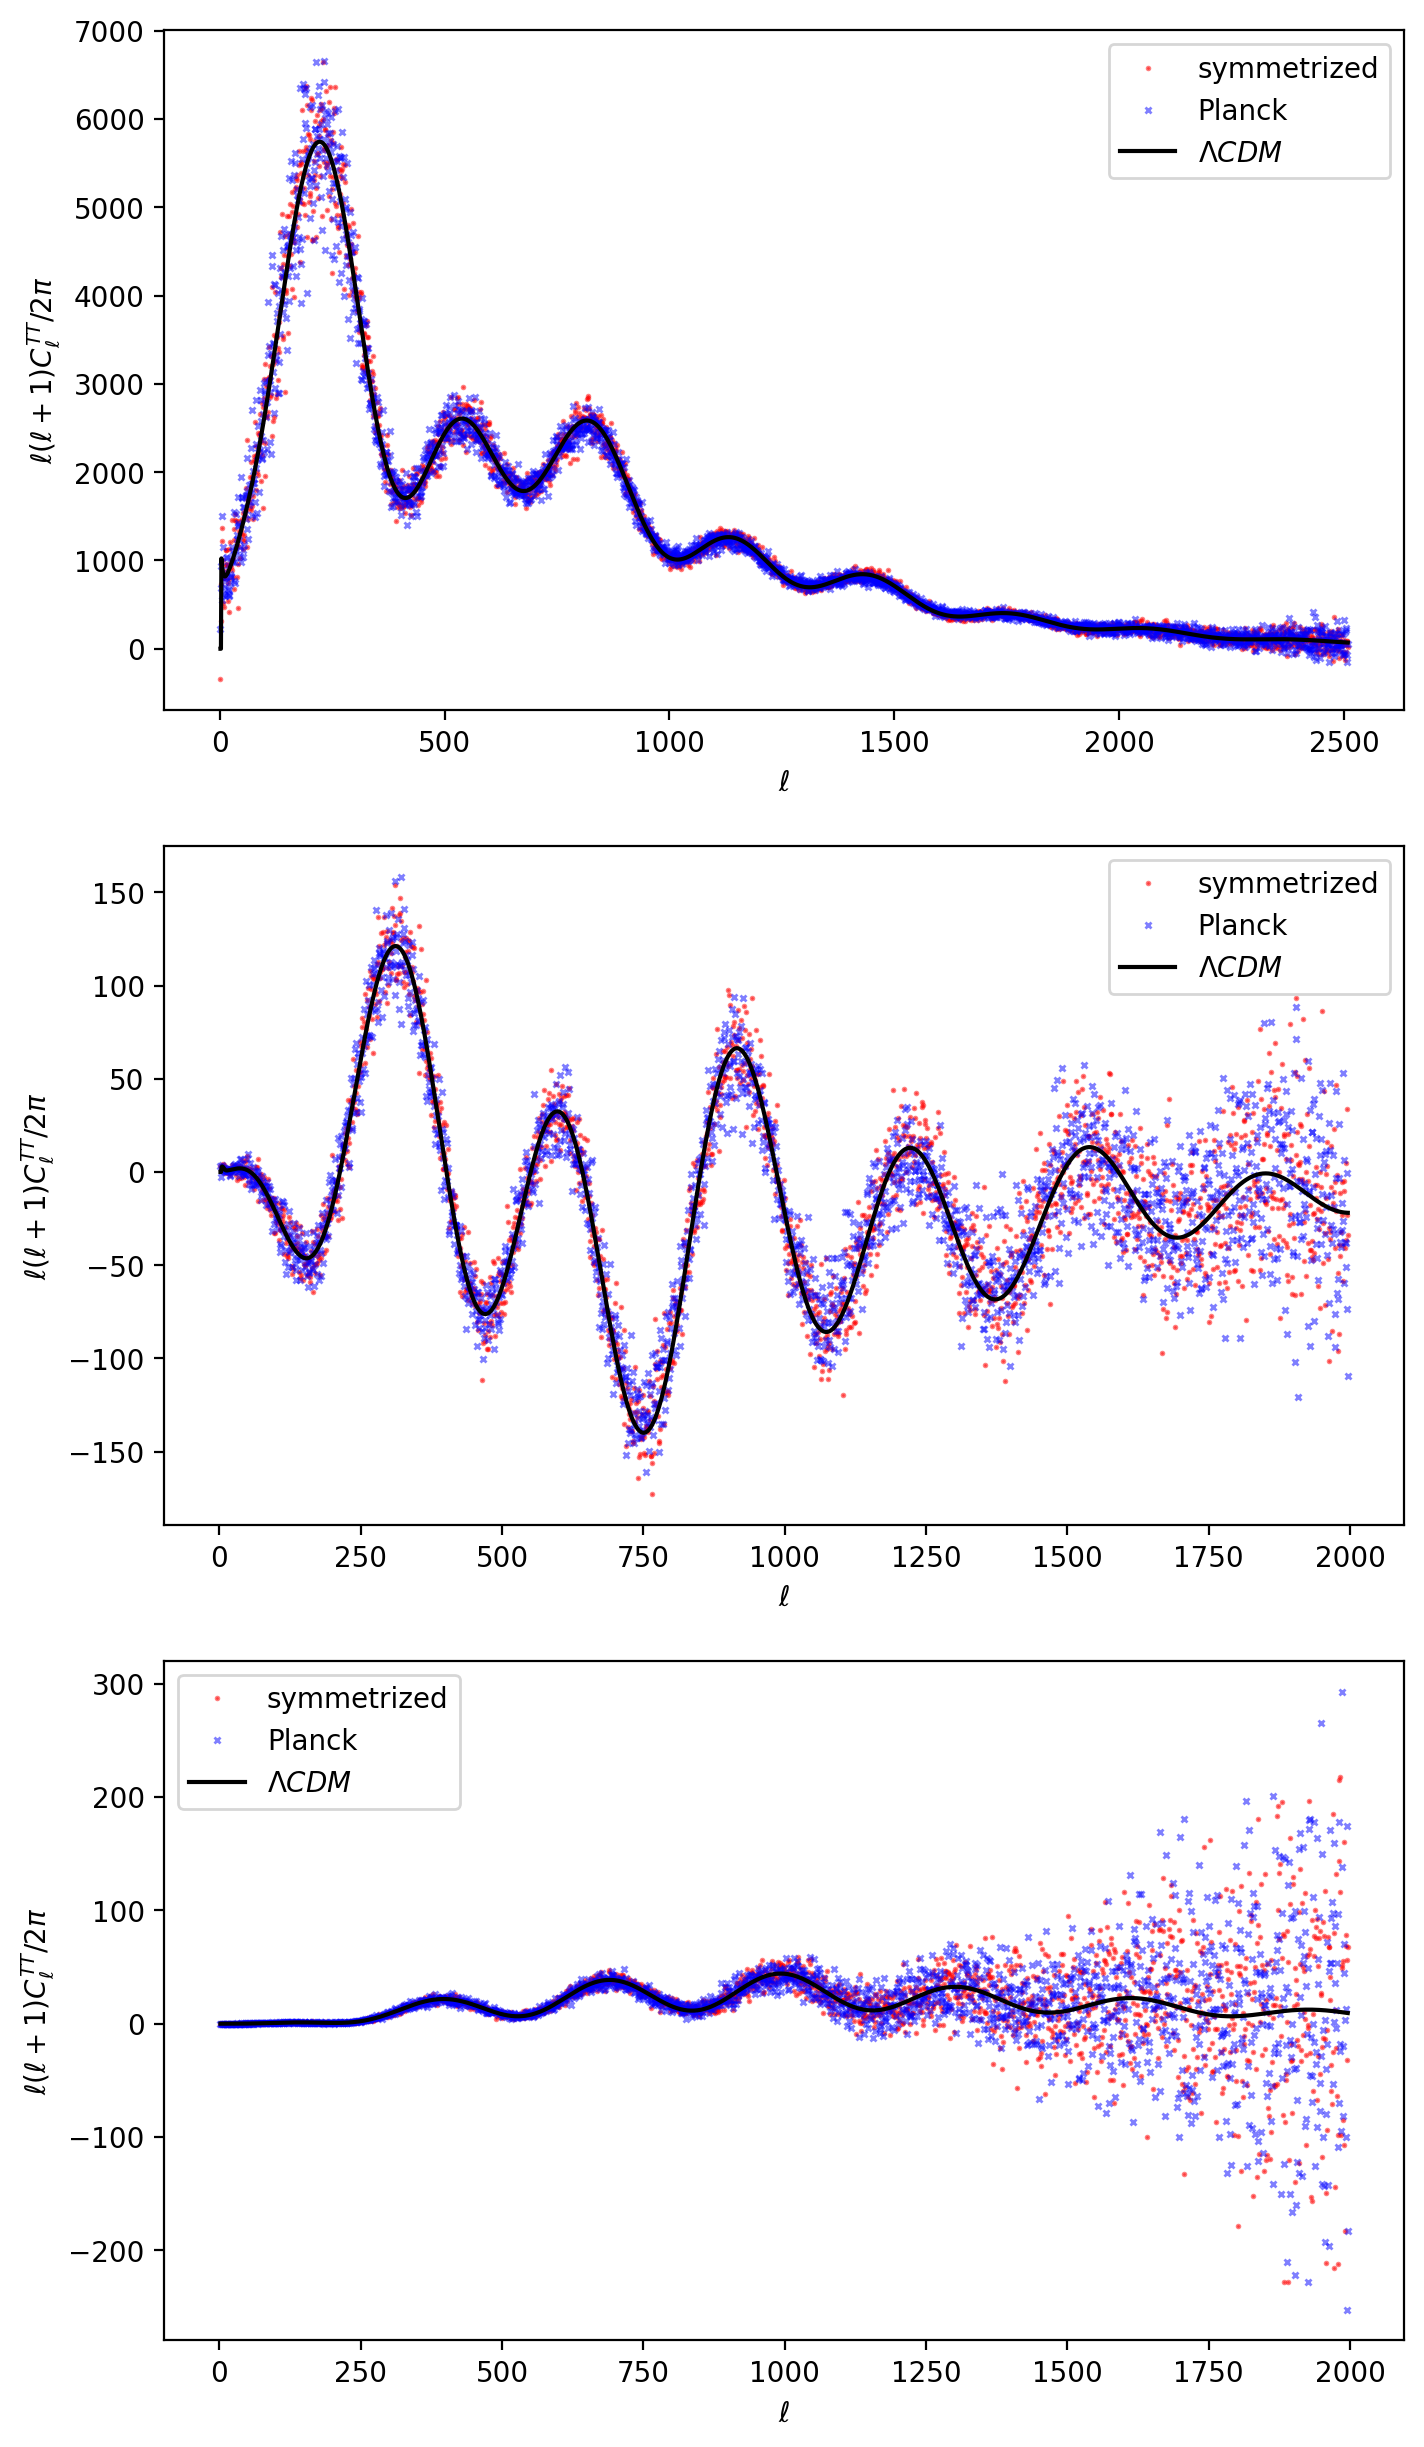

In [8]:
fig, ax = plt.subplots(3,1, figsize = (8,15))

ax[0].plot(round_ls_Pl_TT,dlstt_symmetrized[0], marker='o', color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.5)
ax[0].plot(round_ls_Pl_TT,dl_Planck_TT, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
ax[0].plot(round_ls_Pl_TT,dlstt, color='black', label='$\Lambda CDM$', linestyle='-')
ax[0].set_xlabel('$\ell$')
ax[0].set_ylabel('$\ell(\ell+1)C_{\ell}^{TT}/2\pi$')
ax[0].legend()

ax[1].plot(round_ls_Pl_TE,dlste_symmetrized[0], marker='o', color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.5)
ax[1].plot(round_ls_Pl_TE,dl_Planck_TE, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
ax[1].plot(round_ls_Pl_TE,dlste, color='black', label='$\Lambda CDM$', linestyle='-')
ax[1].set_xlabel('$\ell$')
ax[1].set_ylabel('$\ell(\ell+1)C_{\ell}^{TT}/2\pi$')
ax[1].legend()

ax[2].plot(round_ls_Pl_EE,dlsee_symmetrized[0], marker='o', color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.5)
ax[2].plot(round_ls_Pl_EE,dl_Planck_EE, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
ax[2].plot(round_ls_Pl_EE,dlsee, color='black', label='$\Lambda CDM$', linestyle='-')
ax[2].set_xlabel('$\ell$')
ax[2].set_ylabel('$\ell(\ell+1)C_{\ell}^{TT}/2\pi$')
ax[2].legend()

# MCMC covariance matrix results

In [9]:
dltt_cov_mat_mcmc = np.loadtxt('./simulated_data/dlstt_covariance_matrix.csv', delimiter=",")

In [10]:
np.random.seed(314159)
dlstt_mcmc = np.random.multivariate_normal(dlstt, dltt_cov_mat_mcmc, 1)

(-10.0, 2515.0)

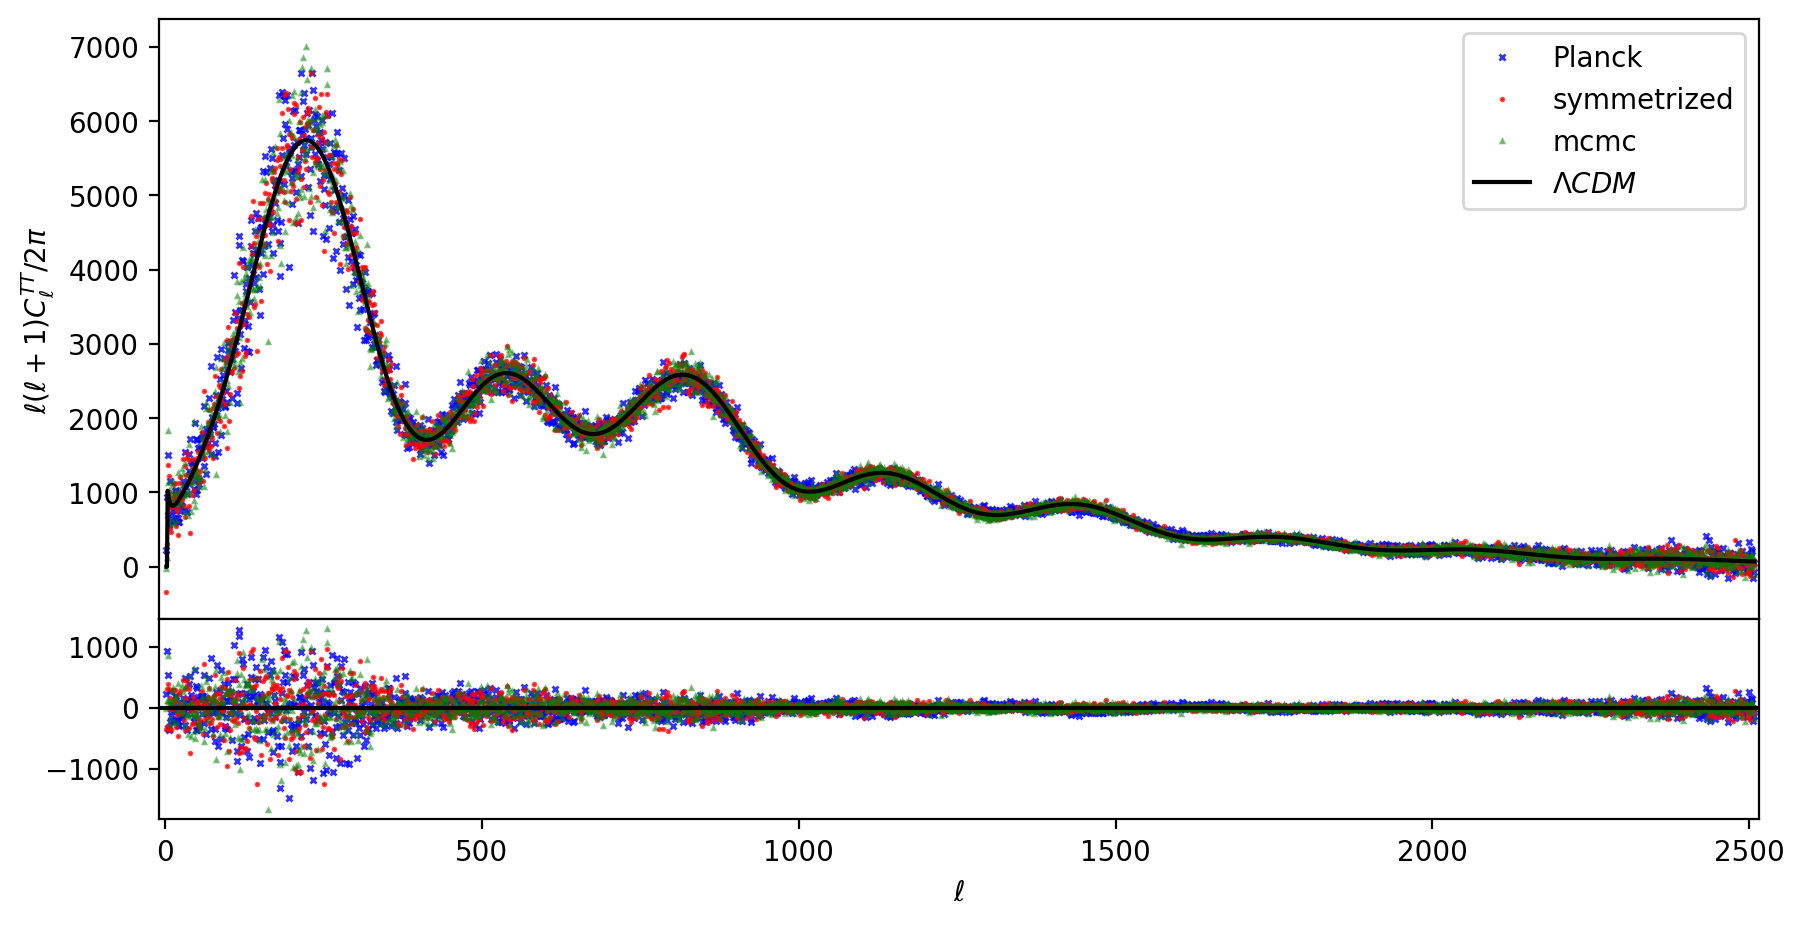

In [14]:
fig = plt.figure(figsize=(10,5))
frame1 = fig.add_axes((.1,.3,.8,.6))

plt.plot(round_ls_Pl_TT,dl_Planck_TT, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.8)
plt.plot(round_ls_Pl_TT,dlstt_symmetrized[0], marker='o' , color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.7)
plt.plot(round_ls_Pl_TT,dlstt_mcmc[0], marker='^', color='green', label='mcmc', linestyle='None', markersize=1, alpha = 0.5)
plt.plot(round_ls_Pl_TT,dlstt, color='black', label='$\Lambda CDM$', linestyle='-')
plt.xlabel('$\ell$')
plt.ylabel('$\ell(\ell+1)C_{\ell}^{TT}/2\pi$')
plt.xticks(fontsize=1)
plt.legend()

# Residual plot
frame2 = fig.add_axes((.1,.1,.8,.2), sharex=frame1) 

diff_planck = []
for i, j in zip(dl_Planck_TT,dlstt):
    diff_planck.append(i - j)
diff_symm = []
for i, j in zip(dlstt_symmetrized[0],dlstt):
    diff_symm.append(i - j) #int because i outputs a .0 number, not integer
diff_mcmc = []
for i, j in zip(dlstt_mcmc[0],dlstt):
    diff_mcmc.append(i - j)

plt.plot(round_ls_Pl_TT, diff_planck, marker='x' , color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.8)
plt.plot(round_ls_Pl_TT, diff_symm, marker='o' , color='red', label='symmetrized', linestyle='None', markersize=1, alpha = 0.7)
plt.plot(round_ls_Pl_TT, diff_mcmc, marker='^' , color='green', label='mcmc', linestyle='None', markersize=1, alpha = 0.5)
frame2.axhline(y=0, color='black', linestyle='-')
plt.xlabel('$\ell$')

plt.xlim(-10,2515)